# Assignment 2 — Keras MNIST Classifier

**DATAX504** · Due end of Week 4

## Tasks
1. Dense classifier on MNIST — test accuracy **without** dropout
2. Same architecture **with** dropout — compare train vs val curves
3. Confusion matrix → worst confused digit pair
4. Explain why `sparse_categorical_crossentropy` is appropriate

## Moodle fields
`a2_repo`, `a2_test_acc`, `a2_test_acc_do`, `a2_worst_pair`, `a2_crossentropy`

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool | OpenCode + Claude Sonnet 5 Anthropic |
| Used for |Assistance with discussion and lookup on sparse_categorical_crossentropy to ensure my understanding of it |
| Verified how | Used the outputs generated in Section 7 (shapes, printed probabilities, manual loss calculations) to verify the AI's explanations were actually correct|
| Not used for | Final written answers in Section 8 - written in own words *had to remove a lot of words - after working through the concepts |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import keras
from keras import layers

## 1. Load MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

num_classes = 10
print(x_train_flat.shape, y_train.shape)

(60000, 784) (60000,)


In [3]:
print(y_train)
print(y_train.shape)

[5 0 4 ... 5 6 8]
(60000,)


## 2. Validation split

In [4]:
val_samples = 10000
x_val = x_train_flat[:val_samples]
y_val = y_train[:val_samples]
x_train_flat = x_train_flat[val_samples:]
y_train = y_train[val_samples:]

print("Train:", x_train_flat.shape[0], "Val:", x_val.shape[0], "Test:", x_test_flat.shape[0])

Train: 50000 Val: 10000 Test: 10000


## 3. Model builder

TODO: adjust hidden units if needed. Keep architecture comparable between runs.

In [5]:
def build_model(use_dropout=False, dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

## 4. Train baseline (no dropout)

In [6]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model(use_dropout=False)
history_baseline = model_baseline.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

test_loss, test_acc = model_baseline.evaluate(x_test_flat, y_test, verbose=0)
print(f"Baseline test accuracy (Moodle a2_test_acc): {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9289 - loss: 0.2443 - val_accuracy: 0.9626 - val_loss: 0.1228
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9725 - loss: 0.0904 - val_accuracy: 0.9733 - val_loss: 0.0872
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9825 - loss: 0.0580 - val_accuracy: 0.9761 - val_loss: 0.0809
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9885 - loss: 0.0368 - val_accuracy: 0.9761 - val_loss: 0.0833
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9773 - val_loss: 0.0821
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9925 - loss: 0.0221 - val_accuracy: 0.9791 - val_loss: 0.0729
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9945 - loss: 0.0172 - val_accuracy: 0.9776 - val_loss: 0.0856
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9948 - loss: 0.0154 - 

## 5. Train with dropout

In [7]:
model_dropout = build_model(use_dropout=True, dropout_rate=0.3)
history_dropout = model_dropout.fit(
    x_train_flat, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1,
)

_, test_acc_do = model_dropout.evaluate(x_test_flat, y_test, verbose=0)
print(f"Dropout test accuracy (Moodle a2_test_acc_do): {test_acc_do:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9192 - loss: 0.2732 - val_accuracy: 0.9592 - val_loss: 0.1323
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9683 - loss: 0.1048 - val_accuracy: 0.9737 - val_loss: 0.0883
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9796 - loss: 0.0686 - val_accuracy: 0.9756 - val_loss: 0.0777
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9752 - val_loss: 0.0783
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9875 - loss: 0.0375 - val_accuracy: 0.9798 - val_loss: 0.0716
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9908 - loss: 0.0274 - val_accuracy: 0.9788 - val_loss: 0.0749
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9927 - loss: 0.0222 - val_accuracy: 0.9786 - val_loss: 0.0837
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9928 - loss: 0.0206 - val_a

## 6. Compare learning curves

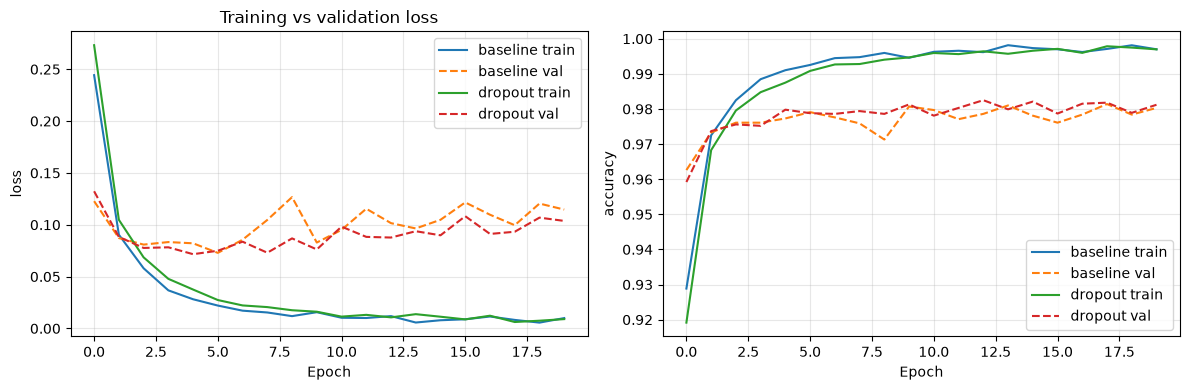

In [8]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(metric)
    axes[0].legend()
    axes[0].set_title(f"Training vs validation {metric}")
    axes[0].grid(True, alpha=0.3)
    # accuracy panel
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], linestyle="--", label=f"{label} val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## 7. Confusion matrix

(10000, 10)
[2.0940609e-15 9.4350925e-12 1.3780471e-15 4.9677847e-15 2.0025623e-15
 3.0039428e-16 2.5119938e-17 1.0000000e+00 3.4274556e-17 8.5543846e-12]
Sum of probabilities: 1.0
y Prob first element for label 7 1.0
-0.0
(10000,)
y Pred first element 7
y training label for first element 7


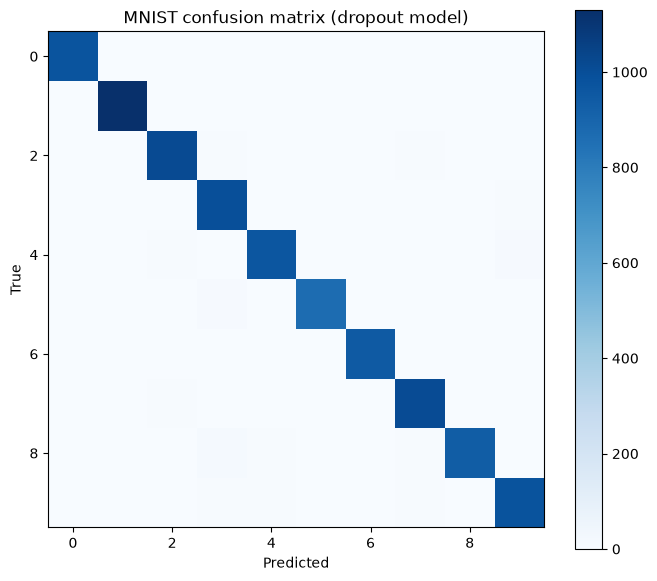

Worst confused pair (Moodle a2_worst_pair): 8-3 (15 errors)


In [9]:
y_prob = model_dropout.predict(x_test_flat, verbose=0)
print(y_prob.shape)        # (10000, 10)
print(y_prob[0]) #layer output by softmax sums to 1 - the 10 probabilities for just the first test image
print("Sum of probabilities:", np.sum(y_prob[0]))  
print(f"y Prob first element for label 7 {y_prob[0][7]}")           # probability for first test image for label 7
loss = -np.log(y_prob[0][7]) #100% probability - 0 loss
print(loss)
y_pred = np.argmax(y_prob, axis=1)
print(y_pred.shape)     # (10000, )
print(f"y Pred first element {y_pred[0]}")           # the prediction from argmax - get the element with highest probablity
print(f"y training label for first element {y_test[0]}") 

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.show()

# TODO: find off-diagonal maximum → worst pair for Moodle a2_worst_pair
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair (Moodle a2_worst_pair): {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

Confusion matrix shape: (10, 10)


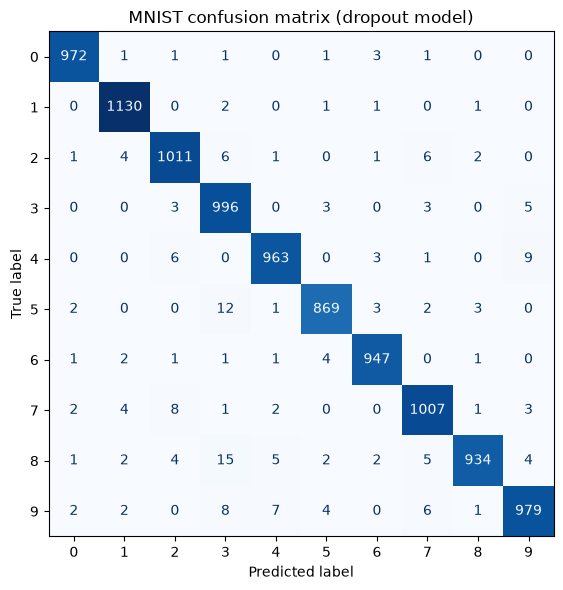

In [10]:
#I wanted to try the confusion matrix from the lecture also
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix shape:", cm.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("MNIST confusion matrix (dropout model)")
plt.tight_layout()
plt.show()

Worst sample index: 3520
True label: 6
Predicted label: 4
Model's confidence in the TRUE label: 0.000000
Full probability array: [2.1712383e-18 3.0027477e-18 4.0589806e-16 5.6887518e-23 1.0000000e+00
 4.1015775e-18 5.5009164e-10 6.8971772e-19 1.6542856e-21 2.9440044e-12]


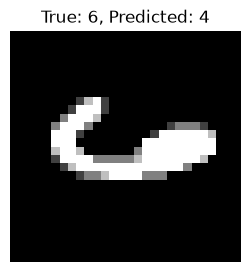

In [11]:
# I wanted to see the worst one 
# Get the model's probability for the TRUE class, for every test image
true_class_probs = y_prob[np.arange(len(y_test)), y_test]

# Find the index where this probability was lowest (worst-performing sample)
worst_idx = np.argmin(true_class_probs)

print(f"Worst sample index: {worst_idx}")
print(f"True label: {y_test[worst_idx]}")
print(f"Predicted label: {y_pred[worst_idx]}")
print(f"Model's confidence in the TRUE label: {true_class_probs[worst_idx]:.6f}")
print(f"Full probability array: {y_prob[worst_idx]}")

# View the actual image
plt.figure(figsize=(3, 3))
plt.imshow(x_test[worst_idx], cmap="gray")
plt.title(f"True: {y_test[worst_idx]}, Predicted: {y_pred[worst_idx]}")
plt.axis("off")
plt.show()

In [12]:
# Example: integer labels vs one-hot encoding
integer_labels = [0, 1, 2]
print("Integer labels:", integer_labels)

print("\nOne-hot encoded:")
for label in integer_labels:
    one_hot = np.zeros(10, dtype=int)
    one_hot[label] = 1
    print(f"label {label} → {list(one_hot)}")

Integer labels: [0, 1, 2]

One-hot encoded:
label 0 → [np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
label 1 → [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
label 2 → [np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


## 8. Why sparse categorical crossentropy? (Moodle `a2_crossentropy`)

Write up to 150 words explaining:
- What integer labels look like vs one-hot
- What the loss computes
- Why this pairs with a softmax output

**Integer labels vs one-hot:**

Doing a print(y_train) shows the labels are current the expected integer value outputs which are the labels for the MNIST images
[3 8 7 ... 5 6 8]

Array shape (50000,) - 50,000 samples one integer label for each image. 

If we one hot encoded instead we would need an output element for each (50000,10) (See example above)


**What the loss computes**

sparse_categorical_crossentropy - calculates how different the model's prediction is from the true label by looking at the probability assigned to the correct class

loss = -np.log(y_prob[0][7]) - example finding the probability of first sample probably for integer 7

- Categorical - because we are doing a multi-class-categorical prediction
- Sparse - because our labels are integers a sparse representation of all the possible values (which would otherwise be one hot encoded - not sparse).



**Why this pairs with a softmax output**

Softmax gives a probability for every class summing to 1.

The 7th element (value 1.0) is then picked via argmax as the predicted label.

Used with the sparse_categorical_crossentropy this allows us to get the loss for the true label during training in order to adjust weights and continue training.

In [13]:
# Example: softmax output for one test image
print(y_prob[0])  # 10 probabilities, one per class, summing to 1
print("Sum:", np.sum(y_prob[0]))

[2.0940609e-15 9.4350925e-12 1.3780471e-15 4.9677847e-15 2.0025623e-15
 3.0039428e-16 2.5119938e-17 1.0000000e+00 3.4274556e-17 8.5543846e-12]
Sum: 1.0
